<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Evidencia 23-04
#### Kala Ariadna Guevara


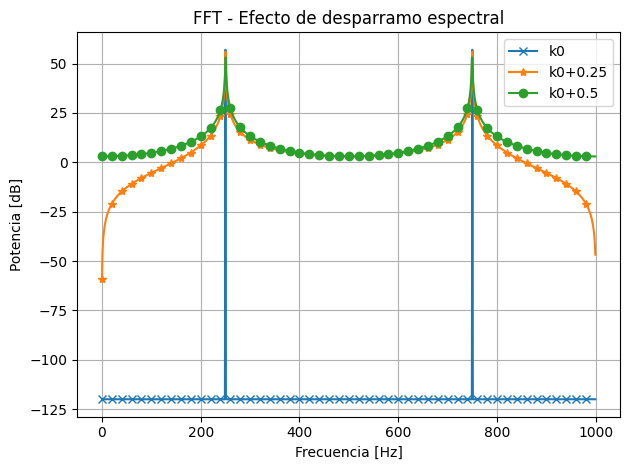

Varianzas:
k0     : 1.0
k0+0.25: 0.9989999999987679
k0+0.5 : 0.9999980125269956
Parseval verificado para k0 ✓
Parseval verificado para k0+0.25 ✓
Parseval verificado para k0+0.5 ✓


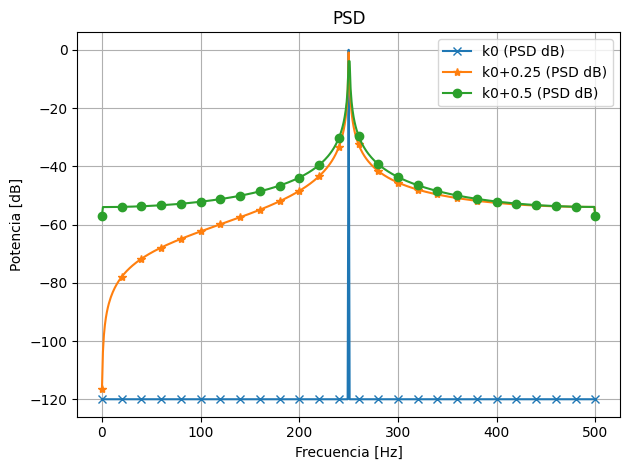

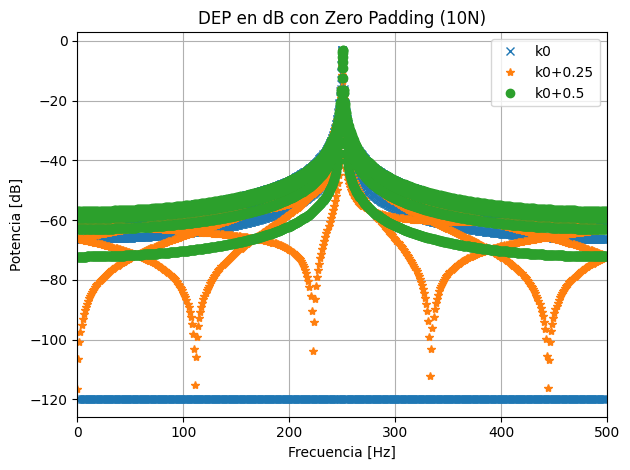

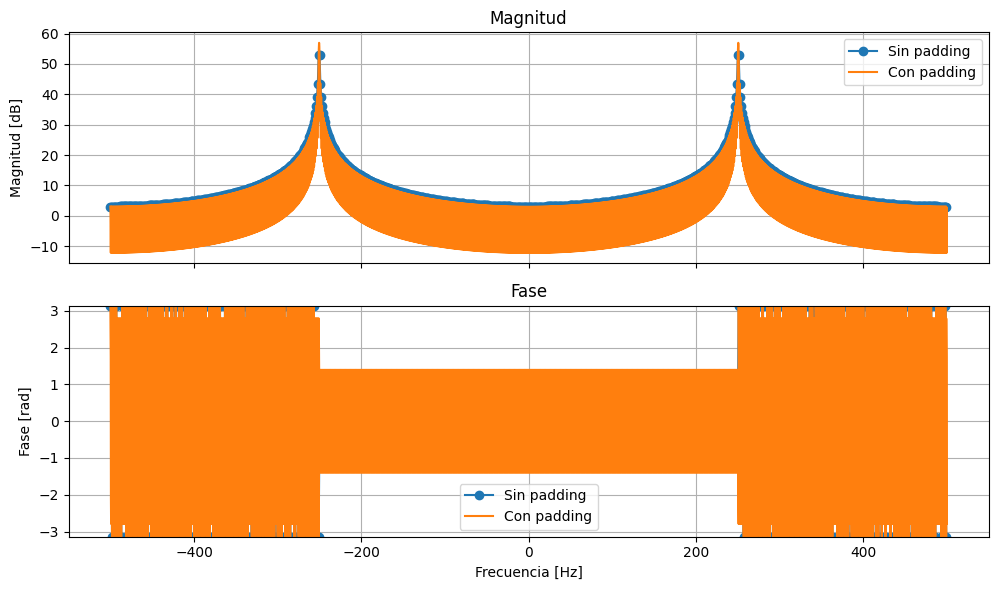

In [1]:
# -*- coding: utf-8 -*-
"""
Created on Thu Apr 23 19:33:55 2026

@author: gueva
"""
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft

#Definición de parámetros
N = 1000       #número de muestras
fs = N         #frecuencia de muestreo
df = fs/N      #resolución espectral
ts = 1/fs      #tiempo entre muestras

def sen(ff, nn, amp=1, dc=0, ph=0, fs=2):
    Nn = np.arange(nn)
    t = Nn/fs
    x = dc + amp * np.sin(2 * np.pi * ff * t + ph)
    return t, x

amp = np.sqrt(2)   

t1, x1 = sen(ff=(N/4)*df, nn=N, fs=fs, amp=amp)
t2, x2 = sen(ff=((N/4)+0.25)*df, nn=N, fs=fs, amp=amp)
t3, x3 = sen(ff=((N/4)+0.5)*df, nn=N, fs=fs, amp=amp)

#transformo
xx1 = fft(x1); xx1abs = np.abs(xx1)
xx2 = fft(x2); xx2abs = np.abs(xx2)
xx3 = fft(x3); xx3abs = np.abs(xx3)

#frecuencias
Ft = np.arange(N)*df

#grafico
plt.figure(1)

step = 20  # cada 20 muestras

plt.plot(Ft, 10*np.log10(xx1abs**2 + 1e-12), '-x', markevery=step, label='k0')
plt.plot(Ft, 10*np.log10(xx2abs**2 + 1e-12), '-*', markevery=step, label='k0+0.25')
plt.plot(Ft, 10*np.log10(xx3abs**2 + 1e-12), '-o', markevery=step, label='k0+0.5')

plt.title('FFT - Efecto de desparramo espectral')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

#verifico varianzas
print("Varianzas:")
print("k0     :", np.var(x1))
print("k0+0.25:", np.var(x2))
print("k0+0.5 :", np.var(x3))

def psd(x):
    X = fft(x)
    # periodograma por bin (full)
    P_full = (np.abs(X)**2) / (N**2)        # P[k] tal que sum_k P[k] = mean power
    # ahora lado único (0..fs/2)
    P1 = P_full[:N//2 + 1].copy()
    if N % 2 == 0:
        P1[1:-1] = P1[1:-1] * 2            # duplicar energía de bandas positivas (excepto DC y Nyquist)
    else:
        P1[1:] = P1[1:] * 2                 # si N impar no hay bin Nyquist separado
    f1 = np.arange(0, N//2 + 1) * df
    return f1, P1, P_full, X

# computo PSDs
f1_1, P1_1, Pfull1, X1 = psd(x1)
f1_2, P1_2, Pfull2, X2 = psd(x2)
f1_3, P1_3, Pfull3, X3 = psd(x3)

tol = 1e-6  #tolerancia

signals = {
    "k0":      (x1, X1),
    "k0+0.25": (x2, X2),
    "k0+0.5":  (x3, X3),
}

for label, (x, X) in signals.items():
    pot_time = np.sum(np.abs(x)**2) #potencia en tiempo
    pot_freq = np.sum(np.abs(X)**2) / N #potencia en frecuencia
    if np.abs(pot_time - pot_freq) < tol:
        print(f"Parseval verificado para {label} ✓")
    else:
        print(f"No se cumple Parseval para {label}")

plt.figure()
step = 20

plt.plot(f1_1, 10*np.log10(P1_1 + 1e-12), '-x', markevery=step, label='k0 (PSD dB)')
plt.plot(f1_2, 10*np.log10(P1_2 + 1e-12), '-*', markevery=step, label='k0+0.25 (PSD dB)')
plt.plot(f1_3, 10*np.log10(P1_3 + 1e-12), '-o', markevery=step, label='k0+0.5 (PSD dB)')

plt.title('PSD')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

#cero padding 
M = 9 * N 
df_p = fs / M 
ff_P = np.linspace(0, (M-1)*df_p, M) 

signals = [x1, x2, x3] 
labels = ["k0", "k0+0.25", "k0+0.5"] 
markers = ['x', '*', 'o'] 

plt.figure() 
plt.title('DEP en dB con Zero Padding (10N)')
 
for sig, lab, mark in zip(signals, labels, markers): 
    padding = np.zeros(M) 
    padding[:N] = sig 
    XX_P = np.fft.fft(padding) 
    DP_P = np.abs(XX_P)**2 / (N**2)
    
    plt.plot(ff_P, 10*np.log10(DP_P + 1e-12), mark, label=lab) 
    
plt.xlim(0, fs/2) 
plt.xlabel('Frecuencia [Hz]') 
plt.ylabel('Potencia [dB]') 
plt.legend() 
plt.grid() 
plt.tight_layout() 
plt.show()

#---------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

x = x3

#sin
X = np.fft.fft(x)
f = np.fft.fftfreq(N, d=1/fs)

#la centras
X_shift = np.fft.fftshift(X)
f_shift = np.fft.fftshift(f)

mag = 20*np.log10(np.abs(X_shift) + 1e-12)
fase = np.angle(X_shift)

# con
M = 9*N
x_pad = np.zeros(M)
x_pad[:N] = x

X_pad = np.fft.fft(x_pad)
f_pad = np.fft.fftfreq(M, d=1/fs)

X_pad_shift = np.fft.fftshift(X_pad)
f_pad_shift = np.fft.fftshift(f_pad)

mag_pad = 20*np.log10(np.abs(X_pad_shift) + 1e-12)
fase_pad = np.angle(X_pad_shift)

# ===============================
# SUBPLOTS: MAGNITUD + FASE ALINEADOS
# ===============================

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(10, 6))

# -------- MAGNITUD --------
axs[0].plot(f_shift, mag, 'o-', label='Sin padding')
axs[0].plot(f_pad_shift, mag_pad, '-', label='Con padding')

axs[0].set_title('Magnitud')
axs[0].set_ylabel('Magnitud [dB]')
axs[0].legend()
axs[0].grid()

# -------- FASE --------
axs[1].plot(f_shift, fase, 'o-', label='Sin padding')
axs[1].plot(f_pad_shift, fase_pad, '-', label='Con padding')

axs[1].set_title('Fase')
axs[1].set_xlabel('Frecuencia [Hz]')
axs[1].set_ylabel('Fase [rad]')
axs[1].set_ylim(-np.pi, np.pi)  # clave para ver los saltos
axs[1].legend()
axs[1].grid()

# -------- AJUSTES --------
plt.tight_layout()
plt.show()